<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/6.0%20Predicting_Customer_Life_Time_Value_(CLTV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
#!pip install boto3 s3fs

### 1.0 INTRODUCTION

The primary objective is of this notebook is to develop a 100-day customer lifetime (CLTV) predictive model, to justify marketing retention, acquisition, and re-acquisition cost. Similar to the churn predictive model, the model learns customer behaviour during the first 60-days of their `Tenure`, to predicted their expected spend.

The dataset was exported, and filtered to records before `2011-08-31`, specifically for training and validation, to develop a deployable model.

In [28]:
import boto3
import sys
import os
import importlib
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, inspect, text
from google.colab import userdata

from datetime import datetime

bucket_name = 'sales-data-analytics-portfolio-2026'

os.environ["AWS_SECRET_ACCESS_KEY"] = userdata.get("AWS_SECRET_ACCESS_KEY")
os.environ["AWS_ACCESS_KEY_ID"] = userdata.get("AWS_ACCESS_KEY_ID")
os.environ["AWS_DEFAULT_REGION"] = "eu-north-1"

parquet_url = "s3://sales-data-analytics-portfolio-2026/parquet_files/fact_online_retail_clean.parquet"

cutoff_date = '2011-08-31'

df = pd.read_parquet(parquet_url)


df = df[df["InvoiceDate"].dt.date.astype('str') <= cutoff_date]
df.info()
df.sort_values("InvoiceDate").head()

<class 'pandas.core.frame.DataFrame'>
Index: 225578 entries, 0 to 225577
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    225578 non-null  object        
 1   StockCode    225578 non-null  object        
 2   Description  225578 non-null  object        
 3   Quantity     225578 non-null  int64         
 4   InvoiceDate  225578 non-null  datetime64[ns]
 5   UnitPrice    225578 non-null  float64       
 6   CustomerID   225578 non-null  float64       
 7   Country      225578 non-null  object        
 8   Revenue      225578 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 17.2+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


### 2.0 `FEATURE ENGINEERING`

Features relating to `tenure` and `recency` were dropped, because the tenure for each client is fixed, and `ObservedLifeSpan` captures Recency. Similar to the churn model, spend after the 60-day Tenure mark, for the next 100 days was calculated as a target. Moreover, the revenue prediction, so that the model learns what spend would look like if a customer spent, excluded all clients that did not shop during the 100-day target period.

To ensure the assumptions were met only clients with an existing 160 days tenure in the customer base were included for training and validation. Nevertheless, for customer distinction sake, the customer personas assigned during customer segmentation were included to the features.

In [29]:
import s3fs

fs = s3fs.S3FileSystem()
function_url = "s3://sales-data-analytics-portfolio-2026/functions/feature_engineering.py"

with fs.open(function_url, "r") as file:
    exec(file.read())


from datetime import timedelta
data = df.groupby("CustomerID").agg(
FirstPurchase = ("InvoiceDate", "min")
).reset_index()

cutoff_days = timedelta(days = 60)
test_end_days = timedelta(days = 100)

data["Cutoff"] = data["FirstPurchase"] + cutoff_days
data["TestEnd"] = data["Cutoff"] + test_end_days


df = df.merge(data, on = "CustomerID", how = "left")
X_features = df[df["InvoiceDate"] <= df["Cutoff"]].copy()

# getting last purchase with first window to compute date to churn by customer
lastpurchase = X_features.groupby(["CustomerID"]).agg(LastPurchase = ("InvoiceDate", "max")).reset_index()

df = df.merge(lastpurchase, on = "CustomerID", how = 'left')

# target is pulled from their last purchase within the first 30days/cutoff, up to 100 days or test end period from that date
y_feature = df[(df["InvoiceDate"] > df["LastPurchase"]) & (df["InvoiceDate"] <= (df["LastPurchase"] + test_end_days))].copy()

X_features.drop(["FirstPurchase", "Cutoff", "TestEnd"], axis = 1, inplace = True)
y_feature.drop(["FirstPurchase", "Cutoff", "TestEnd"], axis = 1, inplace = True)


X_features = feature_engineering(X_features)
y_feature = feature_engineering(y_feature)[["CustomerID", "TotalRevenue", "Frequency", "AOV"]]
y_feature.columns = ["CustomerID", "RevenueTarget", "FrequencyTarget", "AOVTarget"]

X_features = X_features.merge(y_feature, on = "CustomerID", how = "left")

features = X_features.fillna(0)

# Filtering tenure, to ensure each clients has been with the business, at least 160 days
features = features.query('Tenure > 160')

parquet_url = "s3://sales-data-analytics-portfolio-2026/parquet_files/segmented_features.parquet"

segmented_df = pd.read_parquet(parquet_url)
#segmented_df = segmented_df.query('Persona == "One-Time Acquaintance"')
# Merging features with segments
features = features.merge(segmented_df, how = "inner", on = "CustomerID")

# Excluding outliers
features = features[features["RevenueTarget"] < features["RevenueTarget"].quantile(0.95)]
features = features[features["RevenueTarget"] > 0]

from sklearn.model_selection import train_test_split
X = features.drop(['ActiveMRate','TotalRevenue','RevenueTarget','KSegment','AOVTarget','FrequencyTarget', 'RevenueTarget', 'CustomerID', 'CohortMonth', 'Tenure', 'Recency', 'RecencyToTenure', 'LifetimePurchaseDensity', 'LifetimeMRate', 'RelativeSilence'], axis = 1)
X = pd.get_dummies(X, drop_first = True)
columns = X.columns
X = X
X.info()
X.head()

<class 'pandas.core.frame.DataFrame'>
Index: 751 entries, 0 to 1995
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Frequency                      751 non-null    int64  
 1   ProductDiversity               751 non-null    int64  
 2   AvgUnitPrice                   751 non-null    float64
 3   AvgQuantity                    751 non-null    float64
 4   AOV                            751 non-null    float64
 5   ObservedLifeSpan               751 non-null    int64  
 6   ActivePurchaseDensity          751 non-null    float64
 7   AvgIPI                         751 non-null    float64
 8   Persona_Loyal Performer        751 non-null    bool   
 9   Persona_One-Time Acquaintance  751 non-null    bool   
 10  Persona_One-Time Bulk-Buyer    751 non-null    bool   
dtypes: bool(3), float64(5), int64(3)
memory usage: 55.0 KB


,Frequency,ProductDiversity,AvgUnitPrice,AvgQuantity,AOV,ObservedLifeSpan,ActivePurchaseDensity,AvgIPI,Persona_Loyal Performer,Persona_One-Time Acquaintance,Persona_One-Time Bulk-Buyer
0,2,49,2.712667,10.566667,19.786333,50,0.040000,25.5,True,False,False
1,2,17,0.552857,88.000000,40.011429,40,0.050000,20.5,False,False,True
4,1,35,2.748000,34.228571,55.646286,1,1.000000,1.0,False,False,True
7,1,26,2.200000,8.692308,16.696154,1,1.000000,1.0,False,True,False
9,2,89,2.482000,10.722222,19.422444,3,0.666667,2.0,False,True,False


### 3.0 MODEL EVALUATION, AND SELECTION
A 5-split KFold cross validation was implemented across 4 models, to select the one that minimises errors the most.

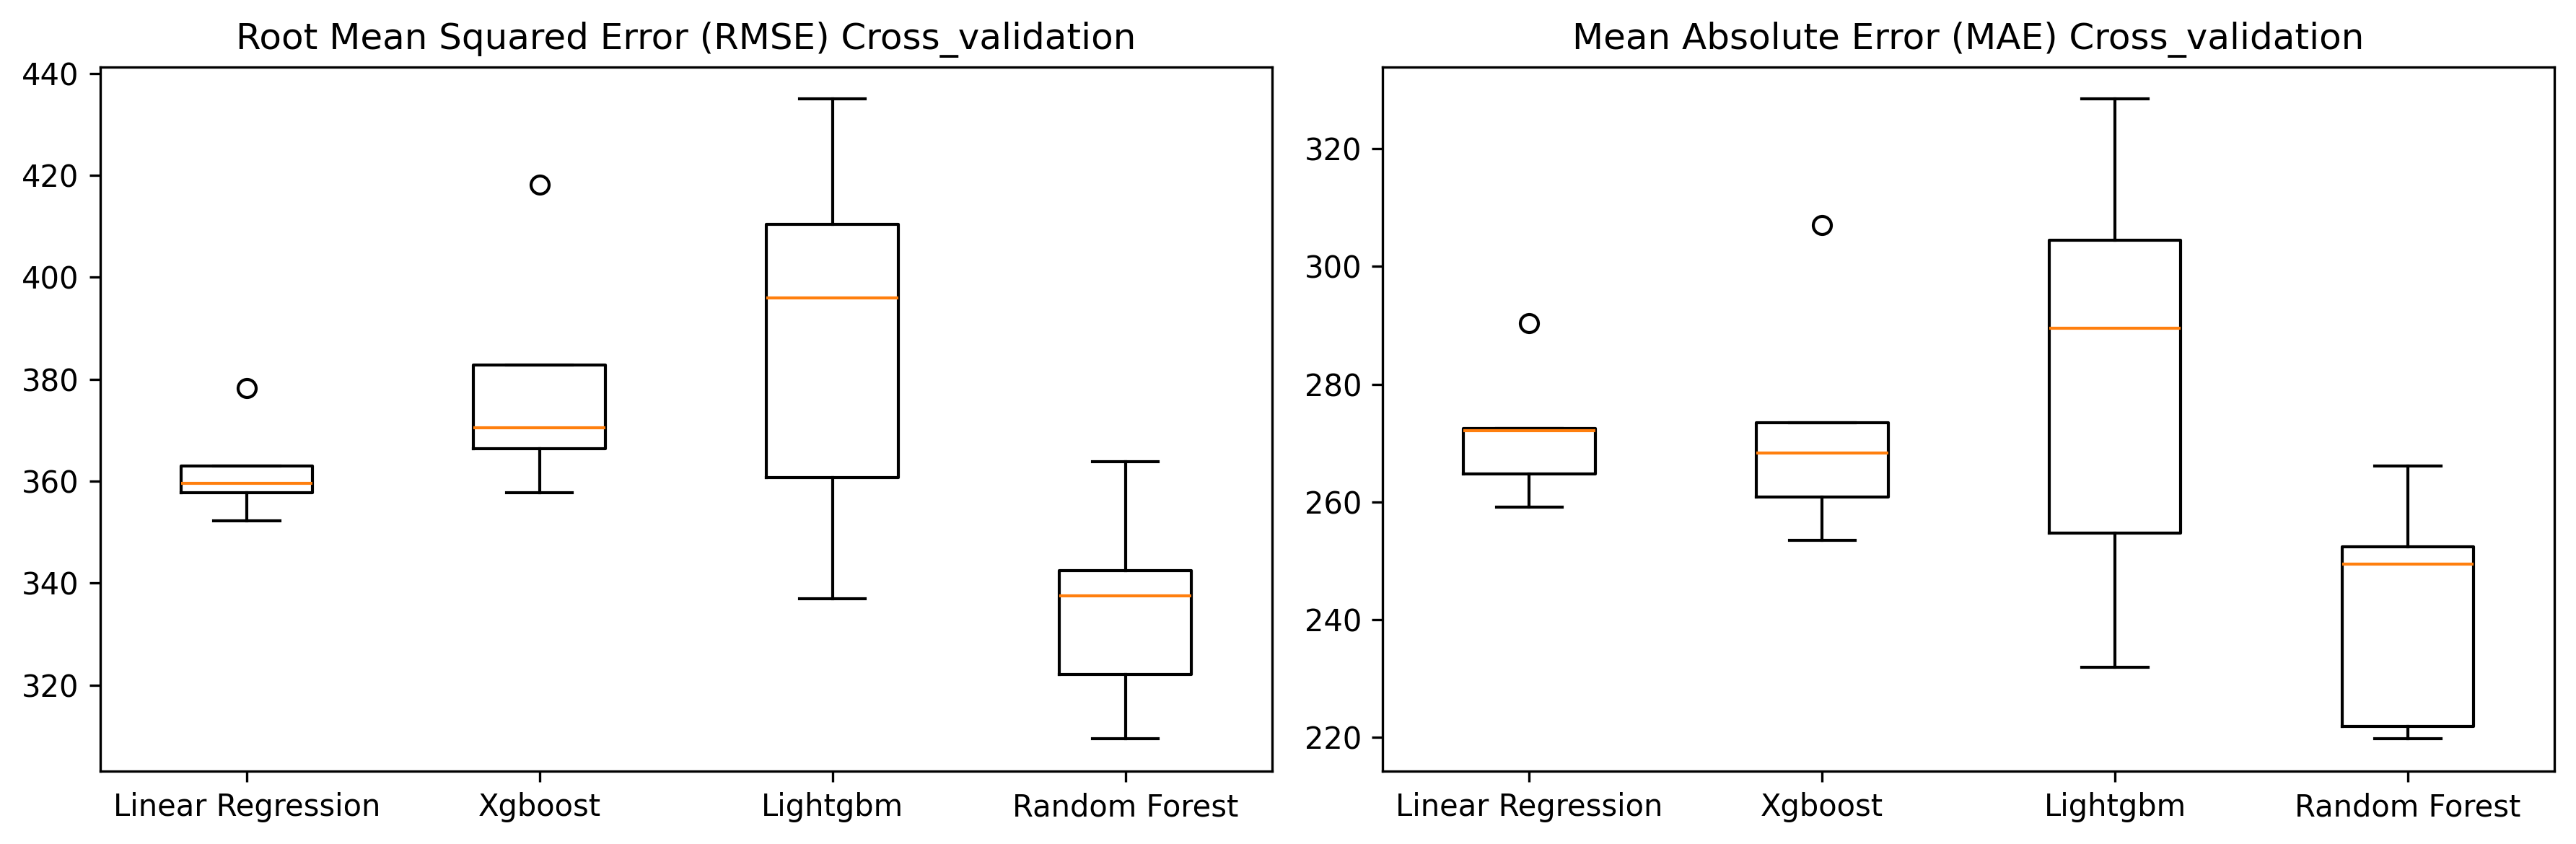

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.decomposition import PCA

from sklearn.model_selection import GroupShuffleSplit

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

y = features['RevenueTarget']

customer_ids = features['CustomerID']

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(X, y, customer_ids, test_size=0.2, random_state = 42)

scaler = StandardScaler()

models = [
   ("Linear Regression", LinearRegression()),
   ("Xgboost", XGBRegressor(n_estimators = 200, max_depth = 6, learning_rate = 0.5, random_state = 42)),
   ("Lightgbm", LGBMRegressor(n_estimators = 200, max_depth = 6, learning_rate = 0.5, random_state = 42)),
   ("Random Forest", RandomForestRegressor(n_estimators = 200, max_depth = 6, min_samples_leaf = 2, random_state = 42))
]

rmse = []
mae = []
model_name = []

for name, model in models:
    wrapped_model = TransformedTargetRegressor(
    regressor = model,
    func = np.log1p,
    inverse_func = np.expm1)


    pipeline = make_pipeline(scaler, model)
    kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
    cv_rmse = cross_val_score(pipeline, X_train, y_train, cv = kf, n_jobs = -1, scoring = "neg_root_mean_squared_error")
    cv_mae = cross_val_score(pipeline, X_train, y_train, cv = kf, n_jobs = -1, scoring = "neg_mean_absolute_error")

    rmse.append(-cv_rmse)
    mae.append(-cv_mae)
    model_name.append(name)


fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,4), dpi = 300)
ax1.boxplot(rmse, tick_labels = model_name)
ax1.set_title("Root Mean Squared Error (RMSE) Cross_validation")
ax2.boxplot(mae, tick_labels = model_name)
ax2.set_title("Mean Absolute Error (MAE) Cross_validation")
plt.tight_layout()
plt.show()

The `Random Forest Regressor` outperformed all the other models, registering the lowest RMSE and MAE as presented above, and was accordingly selected for the task to predict customer spend.

#### 3.1 Training and Evaluating the selected Random Forest Regression Algorithm.

Successfully saved cltv predictive model to S3


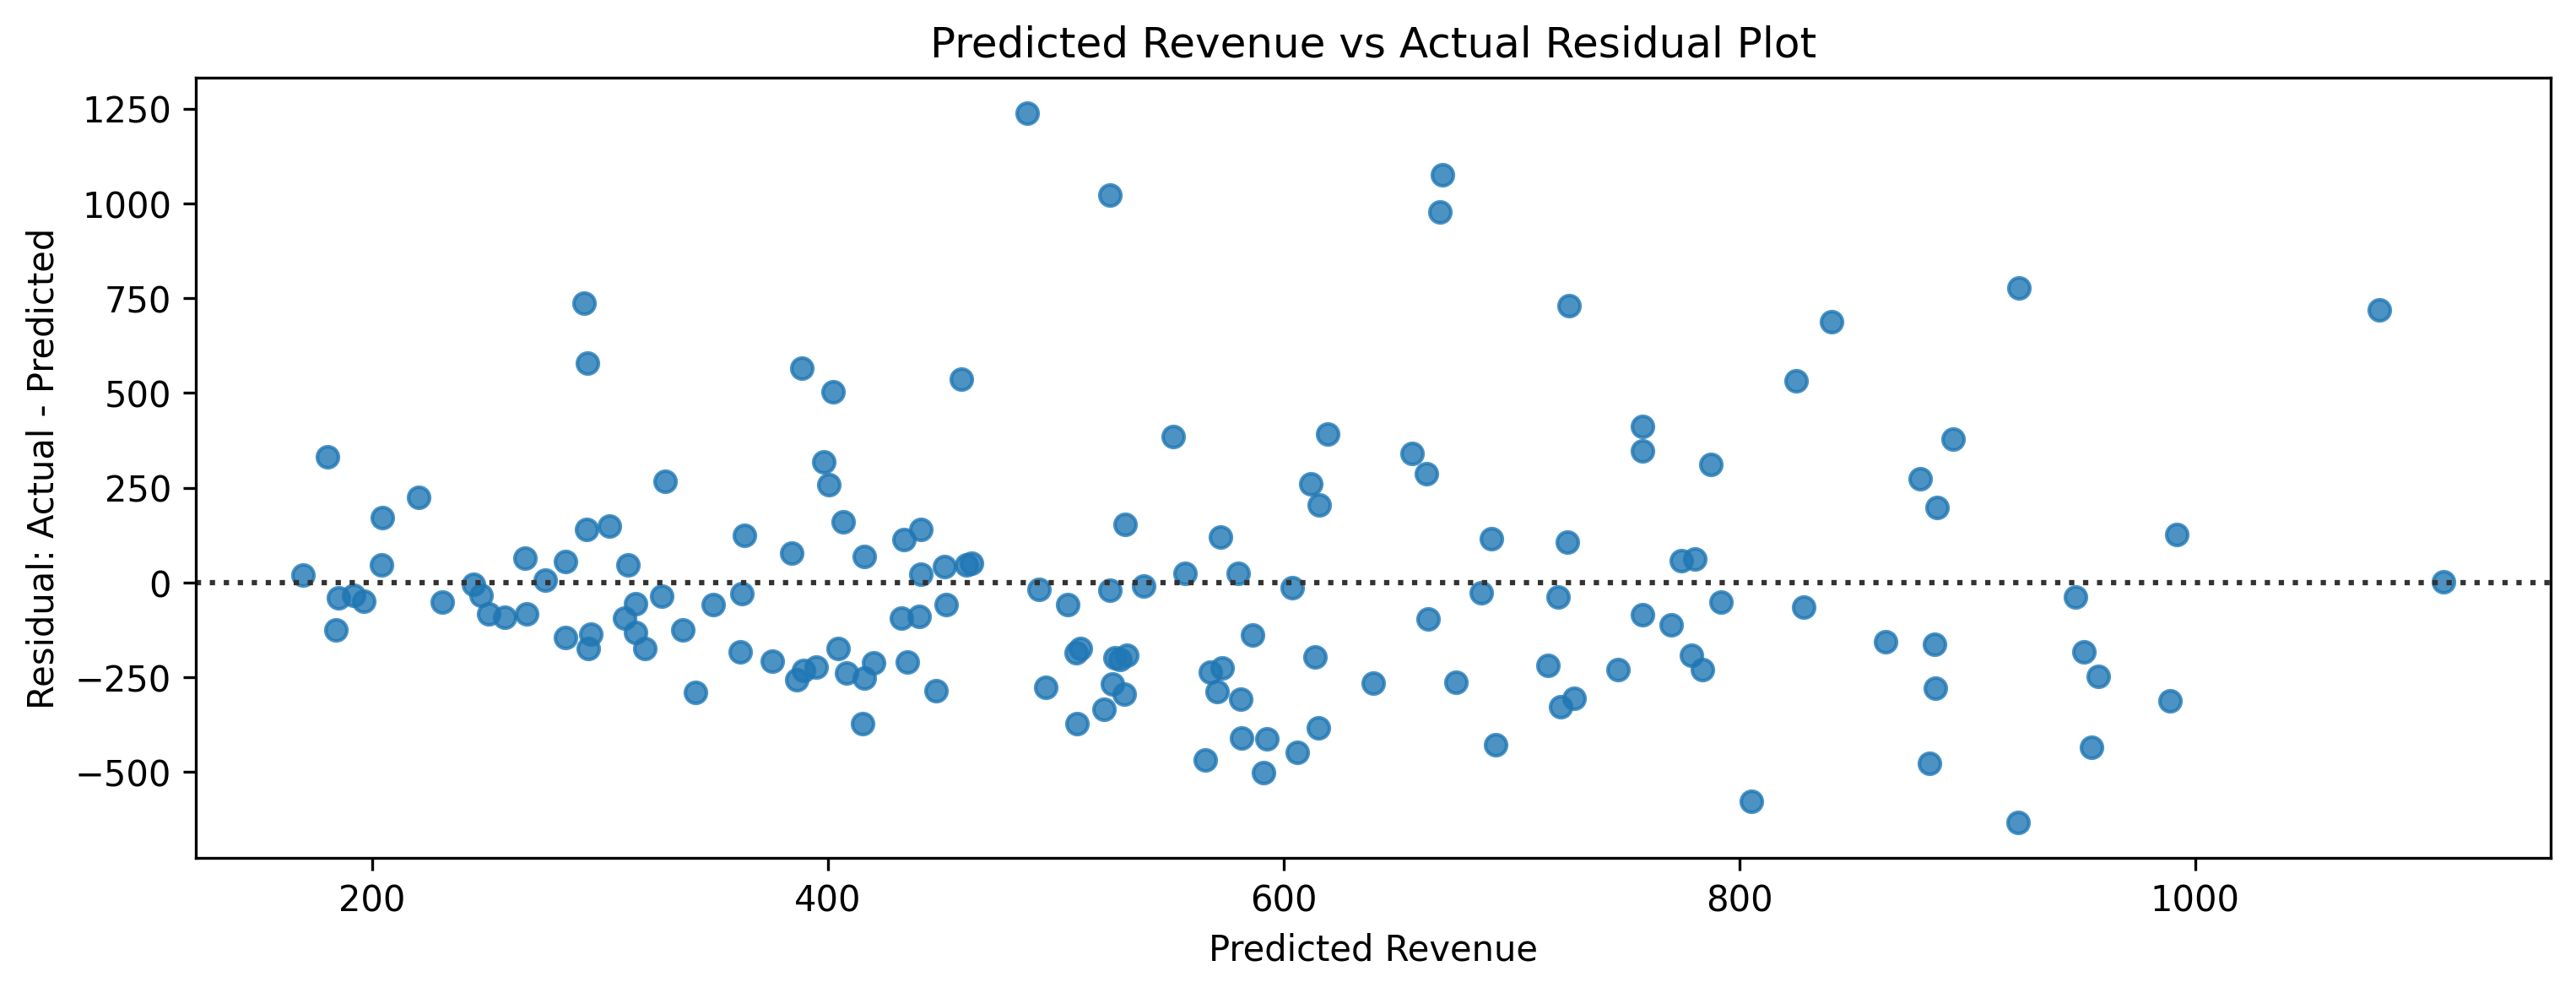

MAE:  246.64, RMSE:  328.00


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import s3fs
import joblib

model = XGBRegressor(n_esimators = 200, max_depth = 6, learning_rate = 0.05, random_state = 42)
model = RandomForestRegressor(n_estimators = 200, max_depth = 6, min_samples_leaf = 2, random_state = 42)

wrapped_model = TransformedTargetRegressor(
    regressor = model,
    func = np.log1p,
    inverse_func = np.expm1)

pipeline = make_pipeline(scaler, model)
pipeline.fit(X_train, y_train)

fs = s3fs.S3FileSystem()
model_path = "s3://sales-data-analytics-portfolio-2026/predictive_models/cltv_model.joblib"

with fs.open(model_path, "wb") as f:
    joblib.dump(pipeline, f)
print("Successfully saved cltv predictive model to S3")

#with fs.open(model_path, "rb") as f:
    #loaded_model = joblib.load(f)
#print("Successfully loaded CLTV model from S3")

y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

plt.figure(figsize = (12,4), dpi = 300)
sns.residplot(x = y_pred, y = y_test)
plt.title('Predicted Revenue vs Actual Residual Plot')
plt.xlabel("Predicted Revenue")
plt.ylabel("Residual: Actual - Predicted")
plt.show()

test_data = X_test.copy()
test_data['ActualRevenue'] =  y_test
test_data['PredictedRevenue'] = y_pred
print(f'MAE: {mae: .2f}, RMSE: {rmse: .2f}')

The residual plot above, presents the error associated with every prediction made, with the model typically misfiring by `$246.64` on average in absolute terms.

#### 4.0 SHAP ANALYSIS
Shap analysis was conducted to identify the most important/impactful features at predicting 100-day Revenue.

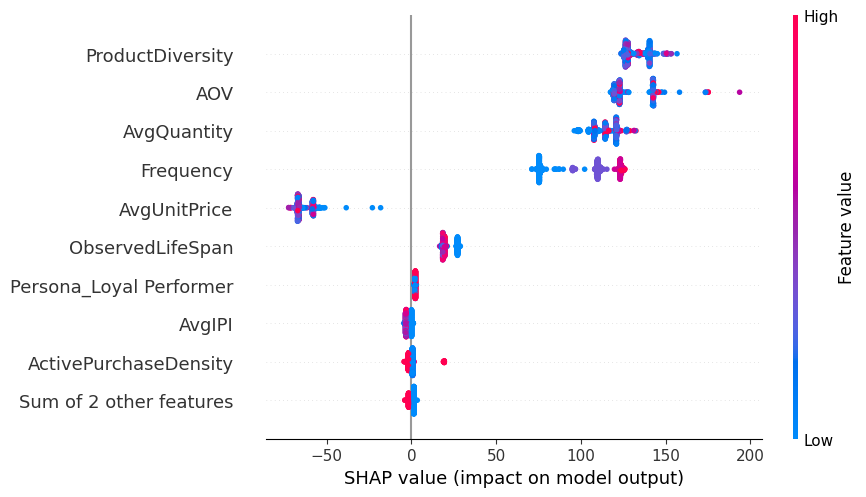

In [32]:
import matplotlib.pyplot as plt
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)  # or X_test

shap.plots.beeswarm(shap_values, max_display=10)

Feature Importance is presented above in order of important from top to bottom, with product diversity standout as the most important predictor.

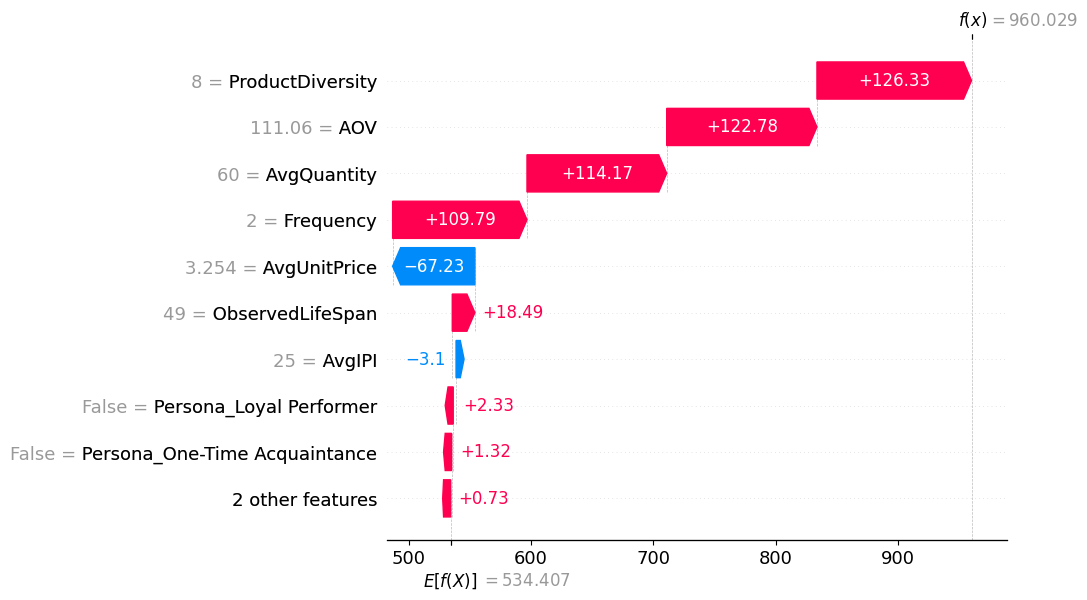

In [33]:
plt.clf()

shap.plots.waterfall(shap_values[0], max_display=10)

To get a glimpse of how the model makes its decision, a single client's prediction was extracted and presented above. Start the model baseline score of `$534.40` any client, the clients `ProductDiversity` of 8 added `$126.33` to the baseline, `AOV` added `$122.78`, their higher average quantity of 60 added `$114.17`, with a frequency of 2 adding `$109.79`, while their high `AvgUnitPrice` was the largest reduction; reducing the prediction by `$67.23`. That said, including the other features, the final prediction for the client in focus ended at `$960`